# ACT PERTEMUAN 12

Adrian Dermawan Budyanto - 240401020213

In [5]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity
from datetime import datetime, UTC

datetime.now(UTC)
plt.style.use('ggplot')

In [8]:
np.random.seed(42)

produk = [
    'Roti',
    'Selai',
    'Susu',
    'Sereal',
    'Telur',
    'Keju',
    'Kopi',
    'Gula',
    'Teh',
    'Mentega'
]

transaksi=[]

for i in range(50):

    n_item=np.random.randint(2,6)

    transaksi.append(
        list(np.random.choice(produk,n_item,replace=False))
    )

# Menambahkan pola tersembunyi
for i in range(20):

    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print("Jumlah transaksi :",len(transaksi))
print(transaksi[:5])


Jumlah transaksi : 50
[[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')], [np.str_('Selai'), np.str_('Keju'), np.str_('Telur'), np.str_('Teh')], [np.str_('Mentega'), np.str_('Susu'), np.str_('Gula'), np.str_('Keju')]]


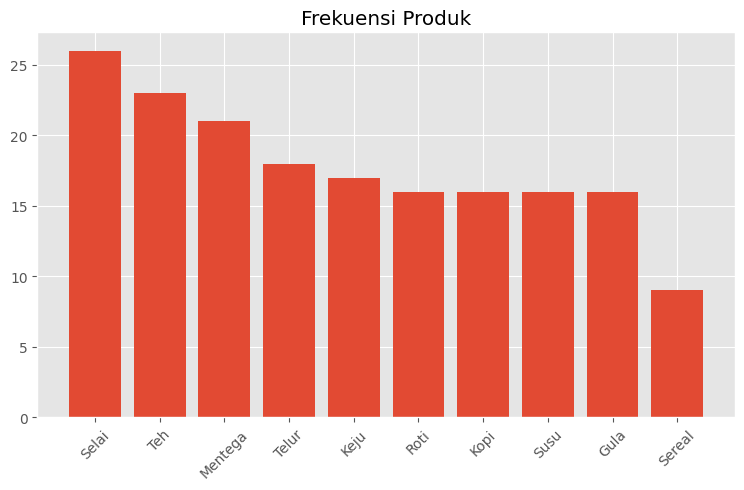

In [9]:
from collections import Counter

counter=Counter()

for t in transaksi:
    counter.update(t)

freq=pd.DataFrame(counter.items(),
                  columns=['Produk','Jumlah'])

freq=freq.sort_values(
    'Jumlah',
    ascending=False
)

plt.figure(figsize=(9,5))
plt.bar(freq['Produk'],freq['Jumlah'])
plt.title("Frekuensi Produk")
plt.xticks(rotation=45)
plt.show()

In [10]:
te = TransactionEncoder()

te_array = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(
    te_array,
    columns=te.columns_
)

df.head()


,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False


In [11]:
for ms in [0.05,0.10,0.20]:

    freq = apriori(
        df,
        min_support=ms,
        use_colnames=True
    )

    print(f"min_support={ms}")
    print("Jumlah itemset :",len(freq))
    print("-"*40)

min_support=0.05
Jumlah itemset : 74
----------------------------------------
min_support=0.1
Jumlah itemset : 44
----------------------------------------
min_support=0.2
Jumlah itemset : 13
----------------------------------------


In [12]:
freq_items = apriori(
    df,
    min_support=0.10,
    use_colnames=True
)

freq_items = freq_items.sort_values(
    'support',
    ascending=False
)

freq_items.head(10)

,support,itemsets
5,0.52,(Selai)
8,0.46,(Teh)
3,0.42,(Mentega)
9,0.36,(Telur)
1,0.34,(Keju)
0,0.32,(Gula)
2,0.32,(Kopi)
4,0.32,(Roti)
7,0.32,(Susu)
36,0.24,"(Teh, Selai)"


In [13]:
rules = association_rules(
    freq_items,
    metric='confidence',
    min_threshold=0.5
)

rules = rules[
    rules['lift']>1
].sort_values(
    'lift',
    ascending=False
)

rules[[
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift'
]].head(10)


,antecedents,consequents,support,confidence,lift
8,"(Teh, Keju)",(Telur),0.12,0.857143,2.380952
14,"(Mentega, Selai)",(Kopi),0.10,0.625000,1.953125
11,"(Roti, Gula)",(Selai),0.10,1.000000,1.923077
7,(Sereal),(Mentega),0.14,0.777778,1.851852
9,"(Teh, Telur)",(Keju),0.12,0.600000,1.764706
15,"(Kopi, Selai)",(Mentega),0.10,0.714286,1.700680
10,"(Keju, Telur)",(Teh),0.12,0.750000,1.630435
12,"(Selai, Gula)",(Roti),0.10,0.500000,1.562500
13,"(Mentega, Kopi)",(Selai),0.10,0.714286,1.373626
1,(Roti),(Selai),0.22,0.687500,1.322115


In [17]:
katalog = pd.DataFrame({

    'produk':produk,

    'kategori':[

        'Bakery',
        'Bakery',
        'Dairy',
        'Bakery',
        'Dairy',
        'Dairy',
        'Minuman',
        'Bumbu',
        'Minuman',
        'Dairy'
    ]

})

fitur = pd.get_dummies(
    katalog['kategori']
)

sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(
        nama_produk,
        top_n=3):

    idx = katalog.index[
        katalog['produk']==nama_produk
    ][0]

    skor = list(
        enumerate(sim_matrix[idx])
    )

    skor = sorted(
        skor,
        key=lambda x:x[1],
        reverse=True
    )

    skor = [
        s for s in skor
        if s[0]!=idx
    ][:top_n]

    return katalog.iloc[
        [i for i,_ in skor]
    ]['produk'].tolist()

    print(rekomendasi_serupa("Roti"))

    produk_target="Roti"

rules_terkait = rules[
    rules['antecedents'].apply(
        lambda x: produk_target in x
    )
]

print("Association Rules")
print(
    rules_terkait[
        ['consequents','lift']
    ].head()
)

print()

print("Content Based")
print(
    rekomendasi_serupa(produk_target)
)

Association Rules
   consequents      lift
11     (Selai)  1.923077
1      (Selai)  1.322115

Content Based
['Selai', 'Sereal', 'Susu']
